In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import boto3
import datetime as dt

try:
    import snowflake.connector
except:
    ! pip install snowflake-connector-python
    import snowflake.connector

from cryptography.hazmat.backends import default_backend
from cryptography.hazmat.primitives.asymmetric import rsa, dsa
from cryptography.hazmat.primitives import serialization

try:
    import optbinning
except:
    ! pip install optbinning

try:
    import catboost
except:
    ! pip install catboost

In [2]:
dtm_now = dt.datetime.now()
print(f'Latest run date: {dtm_now}')

Latest run date: 2025-03-10 23:31:37.929107


#### Functions

In [3]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

#### Constants

In [4]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

# output
str_dirname_output = './output'

Project: 20250307-funded-trends
Task: 02_analysis


#### Make output dir

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import data

In [6]:
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/01_data_collection/{str_filename}'
df = pd.read_parquet(str_uri)
# show
df

,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,SUPER.COM_tag,STEP MOBILE_tag,BRIGHT_tag,FIG TECH INC_tag,SELFBILLSE_tag,PROGRESSRES_tag,FLEX_tag,FLEXFINANCE_tag,sum,has_inst_tag
1,5714239,2021-07-26,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Utah,Franchise,Utah,True,...,0,0,0,0,0,0,0,0,0,0
2,5713063,2021-07-26,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,True,...,0,0,0,0,0,0,0,0,0,0
0,5702434,2021-07-26,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Iowa,Franchise,Iowa,True,...,0,0,0,0,0,0,0,0,0,0
42,5704330,2021-07-27,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Idaho,Franchise,Idaho,True,...,0,0,0,0,0,0,0,0,0,0
41,5704330,2021-07-27,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Idaho,Franchise,Idaho,True,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,8705652,2025-03-07,PRESTIGE-GEN-XIII,nan,1,1,Michigan,Franchise,Michigan,False,...,0,0,0,0,0,0,0,0,1,1
3836,8676945,2025-03-07,PRESTIGE-GEN-XIII,nan,1,1,Pennsylvania,Independent,New Jersey,True,...,0,0,0,0,0,0,0,0,0,0
3763,8712238,2025-03-07,PRESTIGE-GEN-XIII,nan,0,0,Oklahoma,Franchise,Kansas,True,...,0,0,0,0,0,0,0,0,0,0
3702,8605449,2025-03-07,PRESTIGE-GEN-XIII,nan,1,1,Ohio,Franchise,Ohio,True,...,0,0,0,0,0,0,0,0,3,1


#### Mask negatives

In [7]:
list_cols = [
    
]

#### Get the request month

In [8]:
df['request_month'] = df['request_datetime'].apply(
    lambda x: str(x)[:7],
)
# show
df

,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,STEP MOBILE_tag,BRIGHT_tag,FIG TECH INC_tag,SELFBILLSE_tag,PROGRESSRES_tag,FLEX_tag,FLEXFINANCE_tag,sum,has_inst_tag,request_month
1,5714239,2021-07-26,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Utah,Franchise,Utah,True,...,0,0,0,0,0,0,0,0,0,2021-07
2,5713063,2021-07-26,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,True,...,0,0,0,0,0,0,0,0,0,2021-07
0,5702434,2021-07-26,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Iowa,Franchise,Iowa,True,...,0,0,0,0,0,0,0,0,0,2021-07
42,5704330,2021-07-27,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Idaho,Franchise,Idaho,True,...,0,0,0,0,0,0,0,0,0,2021-07
41,5704330,2021-07-27,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Idaho,Franchise,Idaho,True,...,0,0,0,0,0,0,0,0,0,2021-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,8705652,2025-03-07,PRESTIGE-GEN-XIII,nan,1,1,Michigan,Franchise,Michigan,False,...,0,0,0,0,0,0,0,1,1,2025-03
3836,8676945,2025-03-07,PRESTIGE-GEN-XIII,nan,1,1,Pennsylvania,Independent,New Jersey,True,...,0,0,0,0,0,0,0,0,0,2025-03
3763,8712238,2025-03-07,PRESTIGE-GEN-XIII,nan,0,0,Oklahoma,Franchise,Kansas,True,...,0,0,0,0,0,0,0,0,0,2025-03
3702,8605449,2025-03-07,PRESTIGE-GEN-XIII,nan,1,1,Ohio,Franchise,Ohio,True,...,0,0,0,0,0,0,0,3,1,2025-03


#### Number of rows

In [9]:
int_nrows = df.shape[0]
print(f'Number of Rows: {int_nrows}')

Number of Rows: 100031


#### Structure

#### BK

100%|██████████| 1/1 [00:00<00:00, 201.53it/s]


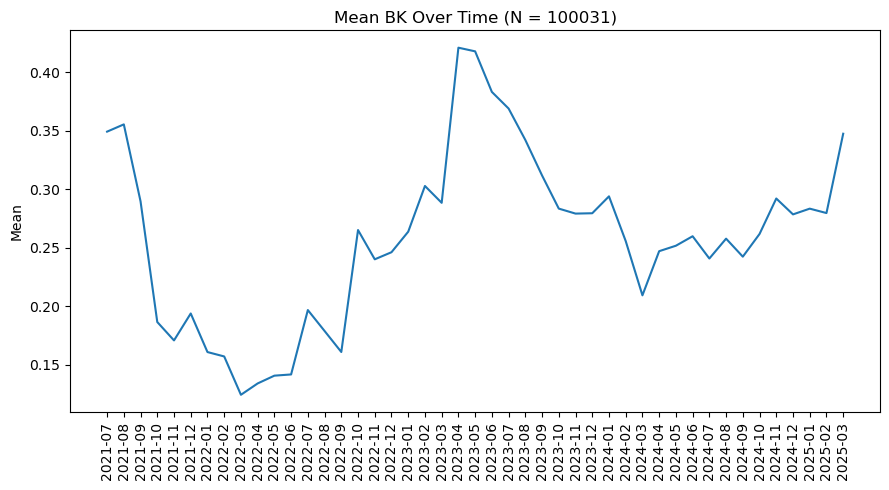

In [10]:
list_cols = [
    'ENG-bk',
]
for col in tqdm(list_cols):
    df[col] = df[col].mask(df[col] <0, np.nan)
dict_agg = {col: 'mean' for col in list_cols}
df_tmp = df.groupby(by='request_month', as_index=False).agg(dict_agg)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean BK Over Time (N = {int_nrows})')
ax.set_ylabel('Mean')
for col in tqdm(list_cols):
    ax.plot(df_tmp['request_month'], df_tmp[col], label=col)
ax.set_xticklabels(df_tmp['request_month'], rotation=90)
#ax.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

#### Income

100%|██████████| 1/1 [00:00<00:00, 211.91it/s]


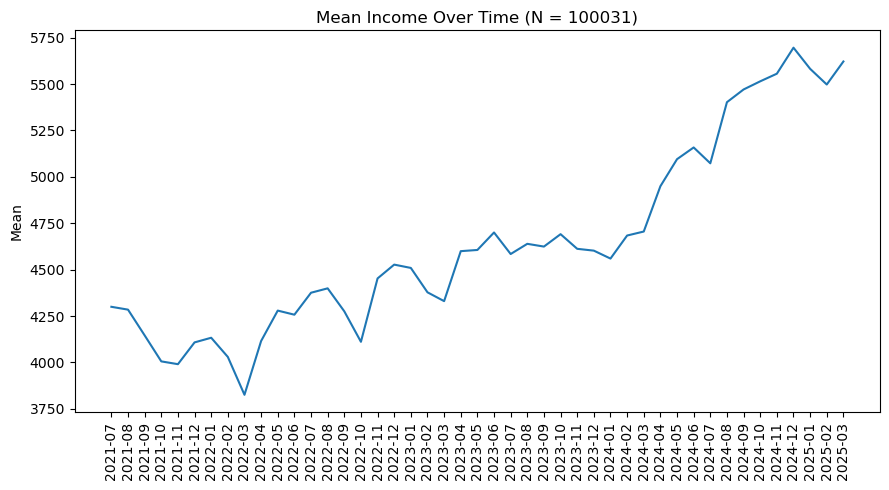

In [11]:
list_cols = [
    'fltgrossmonthly__income_sum',
]
for col in tqdm(list_cols):
    df[col] = df[col].mask(df[col] <0, np.nan)
dict_agg = {col: 'mean' for col in list_cols}
df_tmp = df.groupby(by='request_month', as_index=False).agg(dict_agg)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean Income Over Time (N = {int_nrows})')
ax.set_ylabel('Mean')
for col in tqdm(list_cols):
    ax.plot(df_tmp['request_month'], df_tmp[col], label=col)
ax.set_xticklabels(df_tmp['request_month'], rotation=90)
#ax.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

#### LTV

100%|██████████| 1/1 [00:00<00:00, 215.95it/s]


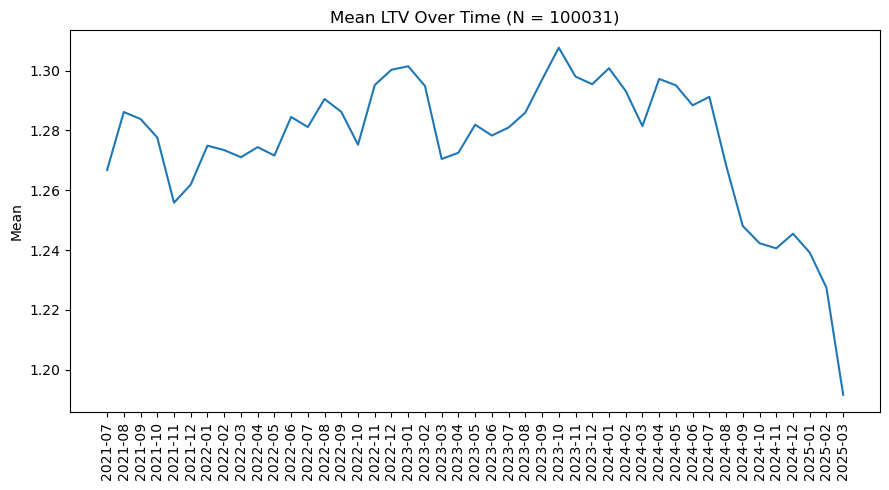

In [12]:
list_cols = [
    'ENG-loan_to_value',
]
for col in tqdm(list_cols):
    df[col] = df[col].mask(df[col] <0, np.nan)
dict_agg = {col: 'mean' for col in list_cols}
df_tmp = df.groupby(by='request_month', as_index=False).agg(dict_agg)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean LTV Over Time (N = {int_nrows})')
ax.set_ylabel('Mean')
for col in tqdm(list_cols):
    ax.plot(df_tmp['request_month'], df_tmp[col], label=col)
ax.set_xticklabels(df_tmp['request_month'], rotation=90)
#ax.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

#### Miles

100%|██████████| 1/1 [00:00<00:00, 10.24it/s]


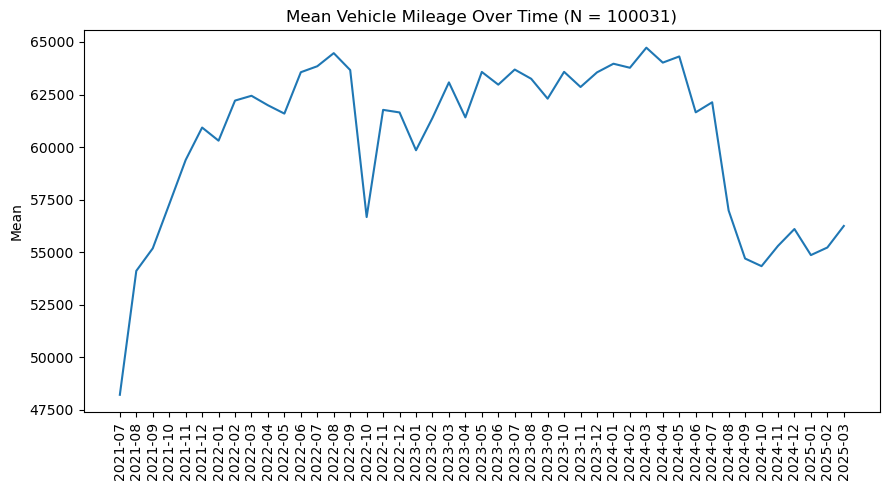

In [13]:
list_cols = [
    'miles_odometer__app',
]
for col in tqdm(list_cols):
    df[col] = df[col].mask(df[col] <0, np.nan)
dict_agg = {col: 'mean' for col in list_cols}
df_tmp = df.groupby(by='request_month', as_index=False).agg(dict_agg)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean Vehicle Mileage Over Time (N = {int_nrows})')
ax.set_ylabel('Mean')
for col in tqdm(list_cols):
    ax.plot(df_tmp['request_month'], df_tmp[col], label=col)
ax.set_xticklabels(df_tmp['request_month'], rotation=90)
#ax.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

#### Payment history

100%|██████████| 3/3 [00:00<00:00, 247.13it/s]


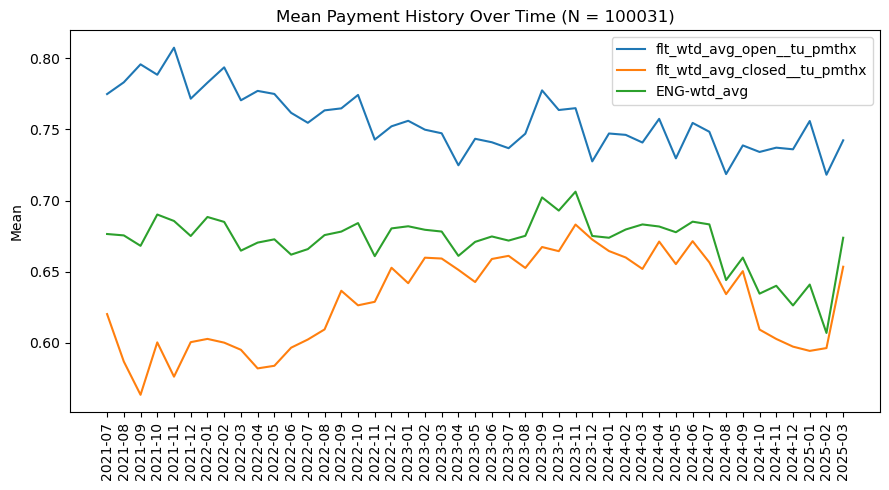

In [14]:
list_cols = [
    'flt_wtd_avg_open__tu_pmthx',
    'flt_wtd_avg_closed__tu_pmthx',
    'ENG-wtd_avg',
]
dict_agg = {col: 'mean' for col in list_cols}
df_tmp = df.groupby(by='request_month', as_index=False).agg(dict_agg)

fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean Payment History Over Time (N = {int_nrows})')
ax.set_ylabel('Mean')
for col in tqdm(list_cols):
    ax.plot(df_tmp['request_month'], df_tmp[col], label=col)
ax.set_xticklabels(df_tmp['request_month'], rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

#### Credit builder tags

100%|██████████| 16/16 [00:00<00:00, 4641.64it/s]


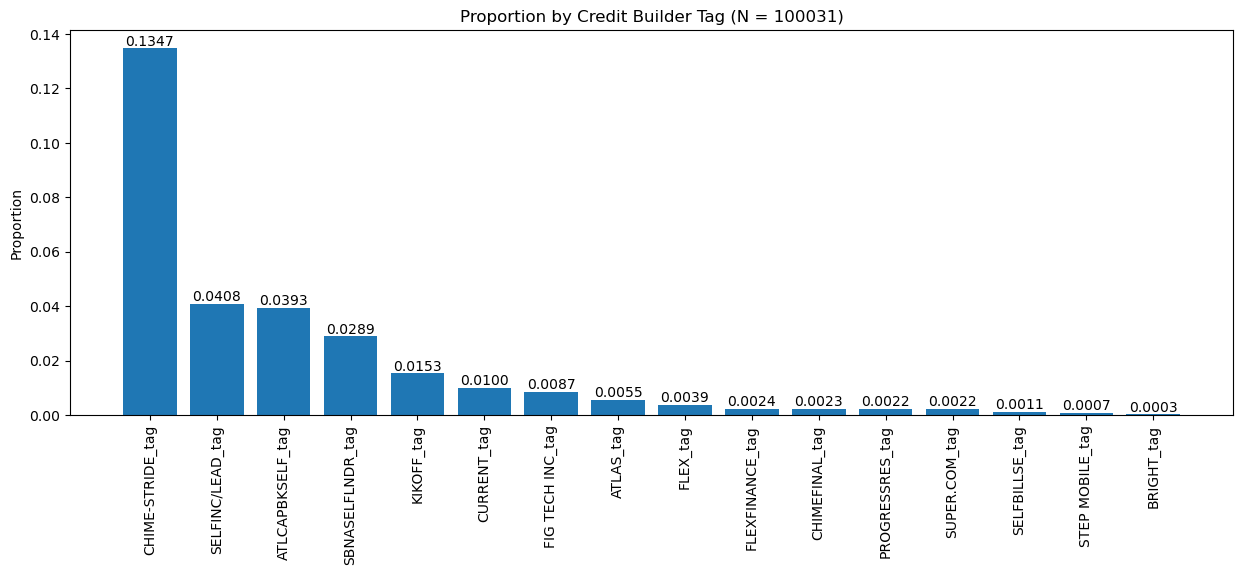

In [15]:
list_cols_ignore = [
    'subjectage__ln',
    'has_inst_tag',
]
list_cols = [col for col in df.columns if 'tag' in col]
list_cols = [col for col in list_cols if col not in list_cols_ignore]

# get proportion
list_dict_row = []
for col in tqdm(list_cols):
    flt_mn = df[col].mean()
    dict_row = {
        'tag': col,
        'prop': flt_mn,
    }
    list_dict_row.append(dict_row)
df_tmp = pd.DataFrame(list_dict_row)
df_tmp.sort_values(by='prop', ascending=False, inplace=True)

# plot
fig, ax = plt.subplots(figsize=(15,5))
ax.set_title(f'Proportion by Credit Builder Tag (N = {int_nrows})')
ax.set_ylabel('Proportion')
bars = ax.bar(df_tmp['tag'], df_tmp['prop'])
ax.bar_label(bars, fmt='%.4f')
ax.set_xticklabels(df_tmp['tag'], rotation=90)
plt.show()

100%|██████████| 15/15 [00:00<00:00, 266.11it/s]


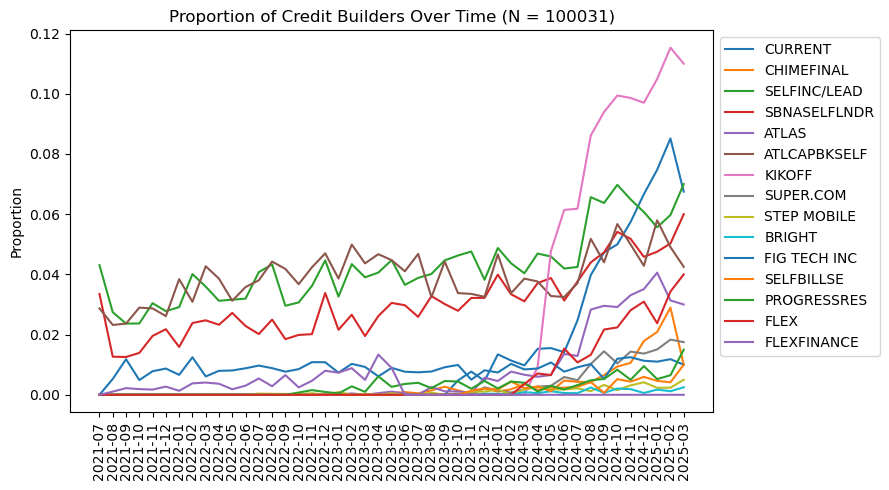

In [16]:
list_cols_ignore = [
    'has_inst_tag',
    'CHIME-STRIDE_tag',
    'subjectage__ln',
]
list_cols = [col for col in df.columns if 'tag' in col]
list_cols = [col for col in list_cols if col not in list_cols_ignore]
dict_agg = {col: 'mean' for col in list_cols}
df_tmp = df.groupby(by='request_month', as_index=False).agg(dict_agg)

fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Proportion of Credit Builders Over Time (N = {int_nrows})')
ax.set_ylabel('Proportion')
for col in tqdm(list_cols):
    ax.plot(df_tmp['request_month'], df_tmp[col], label=col.split('_tag')[0])
ax.set_xticklabels(df_tmp['request_month'], rotation=90)
ax.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

#### Inquiries

100%|██████████| 2/2 [00:00<00:00, 241.42it/s]


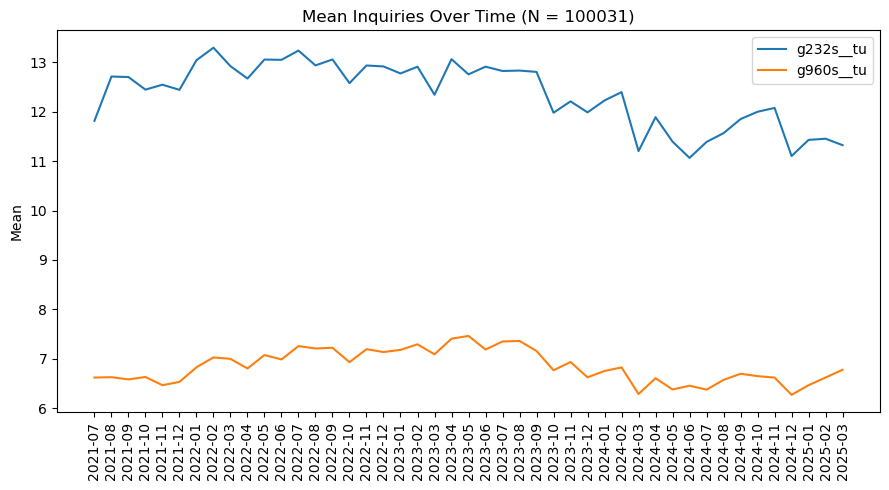

In [17]:
list_cols = [
    'g232s__tu',
    'g960s__tu',
]
for col in tqdm(list_cols):
    df[col] = df[col].mask(df[col] <0, np.nan)
dict_agg = {col: 'mean' for col in list_cols}
df_tmp = df.groupby(by='request_month', as_index=False).agg(dict_agg)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean Inquiries Over Time (N = {int_nrows})')
ax.set_ylabel('Mean')
for col in tqdm(list_cols):
    ax.plot(df_tmp['request_month'], df_tmp[col], label=col)
ax.set_xticklabels(df_tmp['request_month'], rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

#### Repos

100%|██████████| 2/2 [00:00<00:00, 248.24it/s]


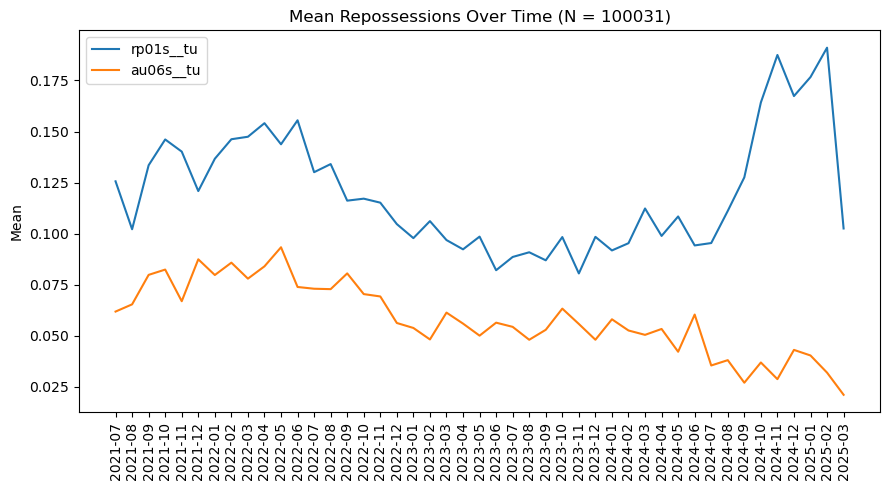

In [18]:
list_cols = [
    'rp01s__tu',
    'au06s__tu',
]
for col in tqdm(list_cols):
    df[col] = df[col].mask(df[col] <0, np.nan)
dict_agg = {col: 'mean' for col in list_cols}
df_tmp = df.groupby(by='request_month', as_index=False).agg(dict_agg)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean Repossessions Over Time (N = {int_nrows})')
ax.set_ylabel('Mean')
for col in tqdm(list_cols):
    ax.plot(df_tmp['request_month'], df_tmp[col], label=col)
ax.set_xticklabels(df_tmp['request_month'], rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

#### Open to buy

100%|██████████| 4/4 [00:00<00:00, 258.24it/s]


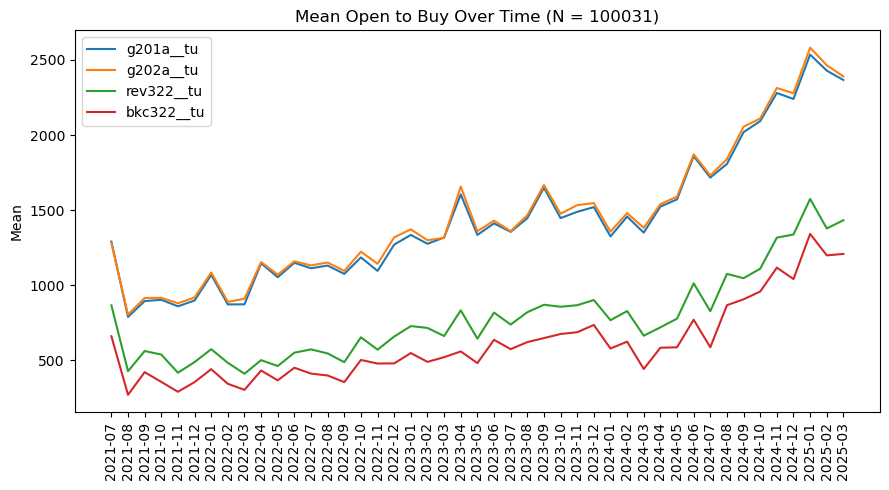

In [19]:
list_cols = [
    'g201a__tu',
    'g202a__tu',
    'rev322__tu',
    'bkc322__tu',
]
for col in tqdm(list_cols):
    df[col] = df[col].mask(df[col] <0, np.nan)
dict_agg = {col: 'mean' for col in list_cols}
df_tmp = df.groupby(by='request_month', as_index=False).agg(dict_agg)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean Open to Buy Over Time (N = {int_nrows})')
ax.set_ylabel('Mean')
for col in tqdm(list_cols):
    ax.plot(df_tmp['request_month'], df_tmp[col], label=col)
ax.set_xticklabels(df_tmp['request_month'], rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

#### Balance magnitude

100%|██████████| 2/2 [00:00<00:00, 237.79it/s]


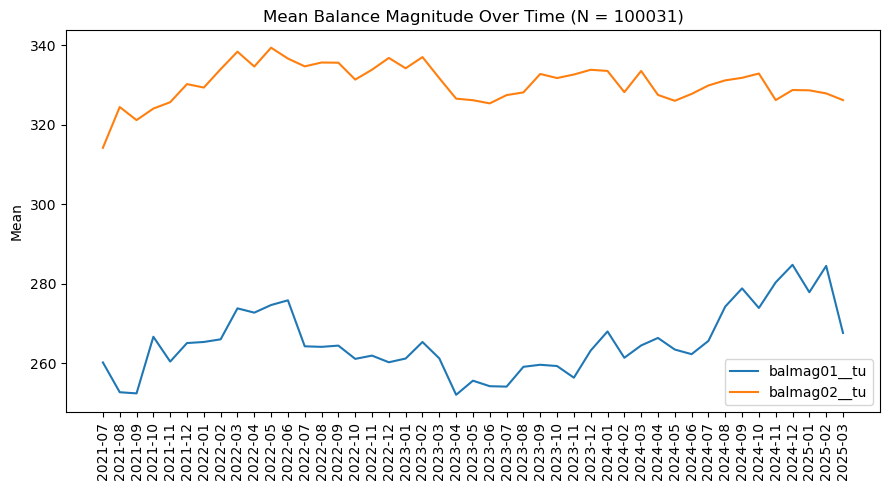

In [20]:
list_cols = [
    'balmag01__tu',
    'balmag02__tu',
]
for col in tqdm(list_cols):
    df[col] = df[col].mask(df[col] <0, np.nan)
dict_agg = {col: 'mean' for col in list_cols}
df_tmp = df.groupby(by='request_month', as_index=False).agg(dict_agg)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean Balance Magnitude Over Time (N = {int_nrows})')
ax.set_ylabel('Mean')
for col in tqdm(list_cols):
    ax.plot(df_tmp['request_month'], df_tmp[col], label=col)
ax.set_xticklabels(df_tmp['request_month'], rotation=90)
ax.legend()
plt.tight_layout()
plt.show()